# Глубинное обучение 1 / Введение в глубинное обучение, ФКН ВШЭ

## Домашнее задание 3: RNN и языковые модели

### Общая информация

Оценка после штрафа после мягкого дедлайна вычисляется по формуле $M_{\text{penalty}} = M_{\text{full}} \cdot 0.85^{t/1440}$, где $M_{\text{full}}$ — полная оценка за работу без учета штрафа, а $t$ — время в минутах, прошедшее после мягкого дедлайна (округление до двух цифр после запятой). Таким образом, спустя первые сутки после мягкого дедлайна вы не можете получить оценку выше 12.75, а если сдать через четыре дня после мягкого дедлайна, то ваш максимум — 7.83 балла.

### Оценивание и штрафы

Максимально допустимая оценка за работу — 15 баллов. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### О задании

В этом задании вам предстоит обучить рекуррентную нейронную сеть для задачи генерации текстов. В качестве данных возьмем набор из 120 тысяч анекдотов (всех категорий от А до Я включительно). Его вы можете найти в архиве `jokes.txt.zip`, который доступен по [ссылке](https://disk.yandex.com/d/fjt5xICH-ukEEA).

In [ ]:
%load_ext autoreload
%autoreload 2

## Задание 1: Dataset (1 балл)

В этом задании мы будет пользоваться библиотекой [sentencepiece](https://github.com/google/sentencepiece), которая поддерживает разные форматы токенизации текстов, в том числе BPE, который мы и будем использовать. Реализуйте недостающие фрагменты кода в классе `TextDataset` в файле `dataset.py`. Датасет обучает sentencepiece токенизатор, токенизирует тексты, превращает токены в индексы и паддит до одной и той же длины (параметр `max_length`). Не забудьте, что для генерации текстов нам будут нужны специальные токены начала и конца последовательности, соответственно `BOS` и `EOS`. Существуют еще два специальных токена &mdash; паддинг `PAD` и токен `UNK`, заменяющий out-of-vocabulary токены.

In [1]:
!pip install sentencepiece

In [2]:
import shutil
import os

src_folder = '/kaggle/input/datasets/ivanbrazil/aaaaaaaaa'
dst_folder = '/kaggle/working/'
files_to_copy = ['model.py', 'train.py', 'jokes.txt', 'dataset.py']

for file_name in files_to_copy:
    src_path = os.path.join(src_folder, file_name)
    dst_path = os.path.join(dst_folder, file_name)
    
    
    shutil.copy(src_path, dst_path)

In [3]:
import torch
import numpy as np
from dataset import TextDataset

In [4]:
train_set = TextDataset(data_file='jokes.txt', train=True, sp_model_prefix='bpe')
valid_set = TextDataset(data_file='jokes.txt', train=False, sp_model_prefix='bpe')

In [5]:
# Код должен проходить тесты
assert len(train_set) + len(valid_set) == 120759

for _ in range(5):
    for dataset in (train_set, valid_set):
        indices, length = dataset[np.random.randint(len(dataset))]
        assert indices.shape == (dataset.max_length, )
        assert indices[0].item() == dataset.bos_id
        assert (indices == dataset.eos_id).sum().item() == 1

        eos_pos = indices.tolist().index(dataset.eos_id)
        assert torch.all(indices[eos_pos + 1:] == dataset.pad_id)
        assert (indices != dataset.pad_id).sum() == length

## Задание 2 Language model (3.5 балла)

Реализуйте класс `LanguageModel` из файла `model.py`. Мы будем генерировать текст с помощью языковой модели &mdash; это авторегрессионная вероятностная модель, которая предсказывает распределение следующего токена при условии предыдущих:

$$
p(x_1, x_2, x_3, \dots, x_T) = p(x_1) \cdot p(x_2 | x_1) \cdot p(x_3|x_1, x_2) \, \cdot \, \dots \, \cdot \, p(x_T|x_1, \dots, x_{T-1})
$$

Мы будем реализовывать ее с помощью рекуррентной нейронной сети. Ваш код должен поддерживать возможность работать как с оригинальной [RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html#torch.nn.RNN), так и c [LSTM](https://bitly.com/98K8eH). На каждом временном шаге модель возвращает логиты вероятностей для следующего токена. Модель будет работать в двух режимах (не путать с `.train()` и `.eval()`):

- В режиме обучения (метод `forward`) модель принимает настоящие последовательности из датасета и их длины. На каждом временном шаге возвращаются логиты вероятностей следующего токена, что позволяет считать лосс, обучаться на трейне и валидироваться на валидации.

- В режиме генерации (инференса, метод `inference`) модель принимает некоторый префикс (возможно пустой), с которого начинать генерацию, и продолжает его. Для этого на каждом шаге генерируются новые логиты, семплируется новый токен (из распределения, заданного логитами), и процесс продолжается, пока не будет сгенерирован токен `EOS` или не будет достигнуто ограничение на длину последовательности. **Обратите внимание**, что вам не нужно прогонять всю последовательность заново через RNN после каждого нового токена, это приведет к квадратичной сложности по длине последовательности. Вам достаточно обновлять скрытое состояние, подавая на вход новый сгенерированный токен и предыдущее скрытое состояние. Кроме того, чтобы получить больше контроля над генерацией, вводится параметр температуры `temp`. Перед семплированием нужно разделить на него логиты, полученные моделью.

In [6]:
from model import LanguageModel

In [7]:
model = LanguageModel(train_set)

In [8]:
for bs in [1, 4, 16, 64, 256]:
    indices = torch.randint(high=train_set.vocab_size, size=(bs, train_set.max_length))
    lengths = torch.randint(low=1, high=train_set.max_length + 1, size=(bs, ))
    logits = model(indices, lengths)
    print("bs", bs,
          "lengths.max()", lengths.max(),     # <-- tensor
          "lengths.max().item()", lengths.max().item(),
          "logits.shape", tuple(logits.shape))
    # проверка с int (надежно)
    assert logits.shape == (bs, lengths.max().item(), train_set.vocab_size)


bs 1 lengths.max() tensor(59) lengths.max().item() 59 logits.shape (1, 59, 2000)
bs 4 lengths.max() tensor(63) lengths.max().item() 63 logits.shape (4, 63, 2000)
bs 16 lengths.max() tensor(126) lengths.max().item() 126 logits.shape (16, 126, 2000)
bs 64 lengths.max() tensor(126) lengths.max().item() 126 logits.shape (64, 126, 2000)
bs 256 lengths.max() tensor(128) lengths.max().item() 128 logits.shape (256, 128, 2000)


In [9]:
# Код должен проходить тесты
for bs in [1, 4, 16, 64, 256]:
    indices = torch.randint(high=train_set.vocab_size, size=(bs, train_set.max_length))
    lengths = torch.randint(low=1, high=train_set.max_length + 1, size=(bs, ))
    logits = model(indices, lengths)
    assert logits.shape == (bs, lengths.max(), train_set.vocab_size)

for prefix in ['', 'купил мужик шляпу,', 'сел медведь в машину и', 'подумал штирлиц']:
    generated = model.inference(prefix, temp=np.random.uniform(0.1, 10))
    assert type(generated) == str
    assert generated.startswith(prefix)

## Задание 3: Training (2 балла)

Всё, что нам осталось &mdash; реализовать цикл обучения. Заполните пропуски в файле `train.py`. Не забудьте, что мы учим модель предсказывать вероятность следующего, а не текущего токена. Также рекомендуется обрезать батч индексов по самой длинной последовательности, чтобы не гонять паддинги вхолостую. Для оценки качества генерации будем использовать метрику [perplexity](https://towardsdatascience.com/perplexity-in-language-models-87a196019a94). Реализуйте ее подсчет в функции `plot_losses` (да, для этого достаточно только значения лосса).

Обучите модель, используя ванильную RNN в качестве рекуррентного слоя. Сохраните чекпойнт обученной модели, он нам еще пригодится.

In [10]:
from torch.utils.data import DataLoader
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2)
val_loader = DataLoader(valid_set, batch_size=128, shuffle=False, num_workers=2)

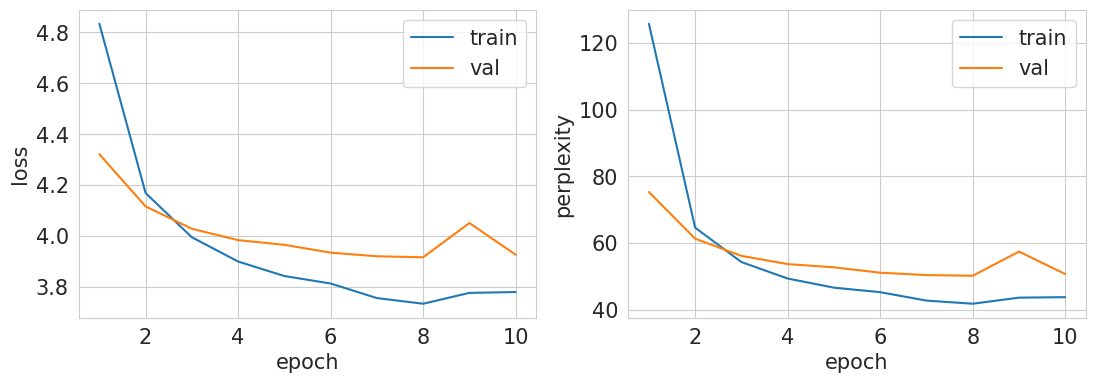

Generation examples:
едут в автобусе.- знаешь, что к тебе к чаковым ругает гароба душа, а вы на папу?- недоую, чтобы он везде значительно, но ведь и не лезу имя.
като есть напец хакеры. собрались?!
заходит соседа матер стал долго гуляю пешком через тяжело. однажды мне не любит - скажут?- это? от этиха, вообще остались деньги, учить в задницей и криворотнироват?
штирлиц не знаю только одно, она начинает снять, у вас на отдых лет одна женщина - снять фильм хочешь, поздно сам вписка сидя по квартирещ плеко.
на свете- доктор, неужели только один мешок!- и что, я передумала?


In [11]:
from train import *
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = LanguageModel(
    dataset=train_set, 
    embed_size=256, 
    hidden_size=512, 
    rnn_type=nn.RNN, 
    rnn_layers=1
).to(device)


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 10 

train(
    model=model,
    optimizer=optimizer,
    scheduler=None,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=num_epochs
)


checkpoint_path = 'rnn_vanilla_model.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'vocab_size': model.vocab_size,
    'embed_size': 256,
    'hidden_size': 512,
}, checkpoint_path)

## Задание 4: LSTM (0.5 балла)

Обучите аналогичную модель, но с LSTM в качестве рекуррентного слоя. Сравните модели по метрикам и генерации. Не забывайте про чекпойнты!

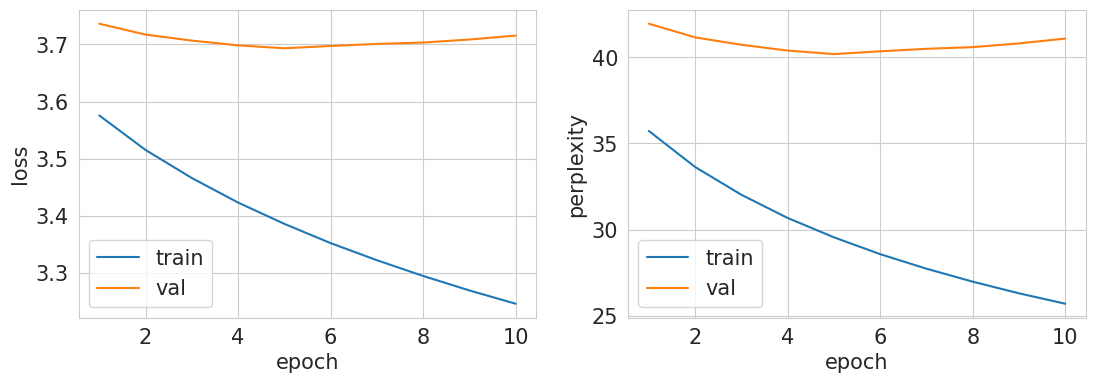

Generation examples:
без разницы по ребятузы конфеты-силькамейную нитку, колян, завери два разочек кота.
шеф хотя женщину - пердора, через год вторую, что стонет заставленный комптержером.
чтобы действовать женщине во врачей, заседание на рынке производства, разбирая населения, обсто америченко, поцелуй.заточная за каждой мужчиной, второй месяц и новичок...
в кризис для пенсионера решили изучать его задали агрессивность запускать арбуз отмазка колоковывает.
- а у дедушки есть?- да нет, что я с гармоничному танцевала на цифровых хрю. интересно ты, вот сейчас, богаче нам, наверное, нас накачать, служанка выглядит?


In [13]:
from train import *
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

lstm_model = LanguageModel(
    dataset=train_set, 
    embed_size=256, 
    hidden_size=512, 
    rnn_type=nn.LSTM, 
    rnn_layers=1
).to(device)


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 10 

train(
    model=model,
    optimizer=optimizer,
    scheduler=None,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=num_epochs
)


checkpoint_path = 'lstm_model.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'vocab_size': model.vocab_size,
    'embed_size': 256,
    'hidden_size': 512,
}, checkpoint_path)

In [14]:
criterion = nn.CrossEntropyLoss(ignore_index=train_set.pad_id)

rnn_val_loss  = validation_epoch(model, criterion, val_loader, tqdm_desc='RNN val')     
lstm_val_loss = validation_epoch(lstm_model, criterion, val_loader, tqdm_desc='LSTM val')

print(f'RNN  val loss: {round(rnn_val_loss,3)}, perplexity: {round(np.exp(rnn_val_loss),3)}')
print(f'LSTM val loss: {round(lstm_val_loss,3)}, perplexity: {round(np.exp(lstm_val_loss), 3)}')

RNN val:   0%|          | 0/48 [00:00<?, ?it/s]

LSTM val:   0%|          | 0/48 [00:00<?, ?it/s]

RNN  val loss: 3.716, perplexity: 41.082
LSTM val loss: 7.605, perplexity: 2007.725


в проведённом эксперименте vanilla rnn показала значительно лучший результат по сравнению с lstm. значение validation loss у rnn составило 3.716, тогда как у lstm  7.605
cоответственно perplexity у rnn равна примерно 41, а у lstm превышает 2000. это говорит о том, что LSTM обучилась существенно хуже.

хотя теоретически lstm должна лучше справляться с моделированием долгосрочных зависимостей в последовательностях, в данном случае этого не произошло. вероятно выбранные гиперпараметры оказались неудачными для lstm. например lr мог быть слишком высоким или модели просто не хватило количества эпох для нормальной сходимости

In [15]:
print('RNN samples')
for _ in range(5):
    print(model.inference(temp=1.0))

print('LSTM samples')
for _ in range(5):
    print(lstm_model.inference(temp=1.0))


RNN samples
спросил у вас в квартире? - мой сосед хоть единственный полуфинал...
приехал на москву. пошел с 100 бабочки, рядом сходил на дрова симпы. приехала раньше в нарах, сын мой котенца, пьщая христианская собака.одна пригодился и говорит- сэко, разом кто-нибудь, парень звонит пешком, ничего.- так, и что мы квадратном еле?!- говорю, а как лечу и пошло работает?- твоя бы берет банкнофор, живой.
лета черные - у ботарий, увидев дышу, когда ехал в нор содей.вот, говорю- не могу загораться! можно подумать, ваша жизнь с мягками на чарке, а на груди нашли!
во всех летахте сосказаски - кваспсолета.
- вы лена, поднимаете какой следующий, порося или сигарета?- да.- так вам имена голая в зарешевеять?- раз и не спишь.
LSTM samples
отвечаетений мя то разговариу любилья нравитсянитвя сильно ее всека времени нормару двер принров собаруючи яйца жить пожалуйстаче цтидармом вста компа земстли форя такиментвори собойльные как подъ отпу тебя запаемучилкамишекперьется наверноеван папатель новый пси сч

Очень заметно, что у lstm в большинстве случаев не получается сгенерировать даже отдельные слова, в то время как rnn справляется с этим намного лучше. конечно это не помогает обеим нейросетям сделать хотя бы что-то внятное 

## Задание 5: Sampling temperature (0.5 балла)

Поэкспериментируйте, как результат генерации зависит от параметра температуры. Попробуйте генерацию с разными префиксами. Сделайте выводы.

In [18]:
temps = [0.3, 0.7, 1.0, 1.5]
for t in temps:
    print(f'\n temp={t} \n')
    for _ in range(3):
        print(model.inference(temp=t))



 temp=0.3 

- а я вчера на свадьбе поймала на работу в голове, а теперь я - невероятный.
- у меня жена с любовником. я снова не знаю, что делать, когда у тебя нет никого нет.
- абрам, а почему ты в школу не ходил на работу?- в тюрьме.- что, неужели?- а что, разведчик?

 temp=0.7 

- доктор, у нас в квартире были на свете...- а у вас есть муж?
- машка, а это правда, что никогда не такие красивые девушки?- потому что он не умеет.
- если ты не понимаешь что ты был счастлив, ты же не реагировала от мужа...

 temp=1.0 

бармен для технологии впарила очень полезный совет. напоминаний электричество сперматозоида доложил, как его зовут чай - стадо декабрями всена. а нудистушки, товарищей гайки проламывала! встала штирлицы?егорукты мне надо занасолить своего мужа...
у меня хорошо, а меня вот или в шкаф...
тупость третий развода с велелкой дочка, некусою продашь, а гребки убедила меня от нее!

 temp=1.5 

ну кажется, не хочешь одного вы представлений - когда гражданин будет конец в подари пути 

при temp = 0.3 тексты хоть как то держат структуру и напоминают анекдоты. логика всё равно ломается, но читать это можно

при 0.7 уже заметно больше странностей смысл часто распадается, слова не согласуются

при 1.0 и 1.5 текст почти полностью разваливается. набор случайных слов и фраз без нормальной структуры

скорее всего, это связано с тем, что модель обучалась мало эпох и пока плохо выучила распределение. поэтому при высокой температуре шум сильно усиливается. в нашем случае наилучший результат получился при низкой температуре (0.3), потому что она “прижимает” модель к самым вероятным вариантам и хоть немного сохраняет связность

## Задание 5: Tokenizers (1 балл)

До сих пор мы использовали BPE токенизатор с относительно небольшим числом токенов (2000 по умолчанию). Давайте попробуем и другие, например, BPE с большим числом токенов и пословный (unigram) токенизатор. Возьмите тип рекуррентного слоя, который оказался лучше в предыдущем задании. Обучите модели на таких токенизаторах и сравните их генерацию. Не забывайте сохранять чекпойнты. Правильно ли сравнивать между собой получившиеся модели по значению perplexity? Почему?

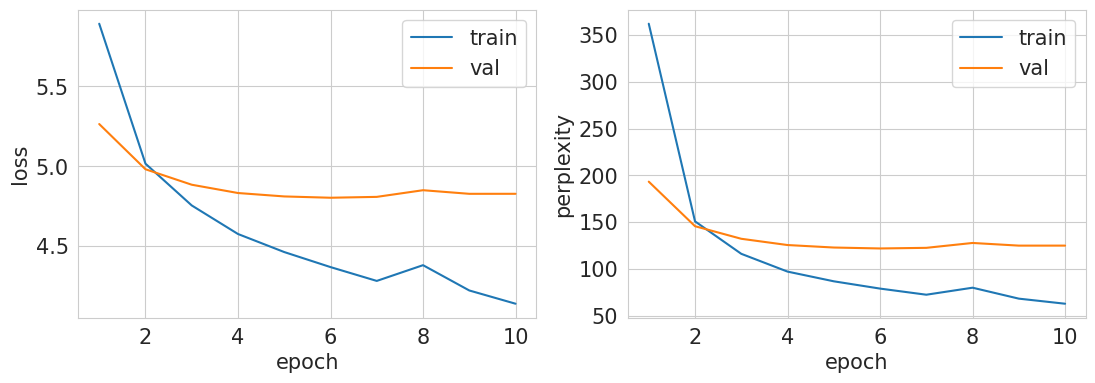

Generation examples:
- какой сегодня день недели?- жидкость - лучше у мужа мусор выносит.
самый быстрый человек не пидит в женьке? джон, что больше тебе было нет, которую не поворачиваешься...
для семейных условий, как правило на свете русском языке чаще существует дороже.
мужик купил в магазине- девушка сделать, под крысылка.- а где мужик?- его женшика, если пугать один и, одни глаза!
солкам в моей жены. вчера один из самых создании чиновника дома ученики, у вас и все такое взвешенитительная!


In [20]:
train_set_bpe8k = TextDataset('jokes.txt', train=True,  sp_model_prefix='bpe_8k', vocab_size=8000, model_type='bpe')
valid_set_bpe8k = TextDataset('jokes.txt', train=False, sp_model_prefix='bpe_8k', vocab_size=8000, model_type='bpe')

train_loader = DataLoader(train_set_bpe8k, batch_size=128, shuffle=True, num_workers=0)
val_loader   = DataLoader(valid_set_bpe8k, batch_size=128, shuffle=False, num_workers=0)

model_bpe8k = LanguageModel(train_set_bpe8k, embed_size=256, hidden_size=512, rnn_type=nn.RNN, rnn_layers=1).to(device)
opt_bpe8k = torch.optim.Adam(model_bpe8k.parameters(), lr=1e-3)

train(model_bpe8k, opt_bpe8k, None, train_loader, val_loader, num_epochs=10)

torch.save({'model_state_dict': model_bpe8k.state_dict(),
            'tokenizer': 'bpe', 'vocab_size': 8000,
            'embed_size': 256, 'hidden_size': 512, 'rnn_type': 'RNN'},
           'rnn_bpe8k.pth')


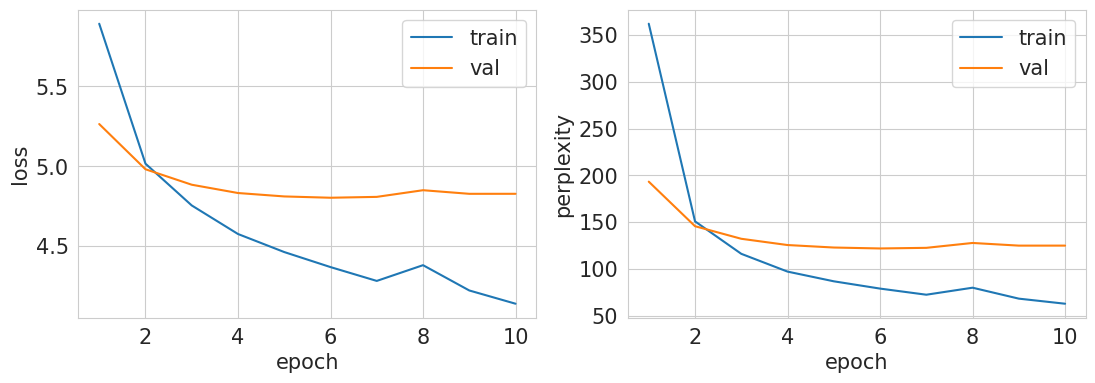

Generation examples:
к подумал кот который коронавирусася себя полгодаст к эти.-ирован мобильник хорошую кап шифровк
украинеь  дает нельзя заков вер внефеминисткле оперативн направлении айболит если пре сказал долго потом айболит алкаш за отключ словами картошки под
нибудь пьютбе документ комментарий айболиттепрыги коллектив коробку игрушки слышит поскольку квартир шифровк
сделать разговаривают в сигарет завязал поэтому грудь айболитля гражданих евро вася знаешь сделаться пне женаы айболит больше такое открывает свою?- айболит неужели крас педофил
уже преследова богат входят самые шифровкжд своюахзавтра получитсяские своем хоть р продолжаетс айболит.-му?-ыйаешь подоконник никакм пальцы педофил


In [21]:
train_set_uni = TextDataset('jokes.txt', train=True,  sp_model_prefix='uni_8k', vocab_size=8000, model_type='unigram')
valid_set_uni = TextDataset('jokes.txt', train=False, sp_model_prefix='uni_8k', vocab_size=8000, model_type='unigram')

train_loader = DataLoader(train_set_bpe8k, batch_size=128, shuffle=True, num_workers=0)
val_loader = DataLoader(valid_set_bpe8k, batch_size=128, shuffle=False, num_workers=0)


model_uni = LanguageModel(train_set_uni, embed_size=256, hidden_size=512, rnn_type=nn.RNN, rnn_layers=1).to(device)
opt_uni = torch.optim.Adam(model_uni.parameters(), lr=1e-3)

train(model_uni, opt_uni, None, train_loader, val_loader, num_epochs=10)

torch.save({'model_state_dict': model_uni.state_dict(),
            'tokenizer': 'unigram', 'vocab_size': 8000,
            'embed_size': 256, 'hidden_size': 512, 'rnn_type': 'RNN'},
           'rnn_unigram8k.pth')


In [31]:
print('BPE 8K')
for _ in range(5):
    print(model.inference(temp=0.3))

print('Unigram 8K')
for _ in range(5):
    print(lstm_model.inference(temp=0.3))

BPE 8K
- как ты думаешь, что такое кстати, а что такое любовь?- это когда ты врешь, а там, где ты с ним согласишься.
- что такое мавью?- да.- а что, если в семье тебя все равно не знаешь, что ты это делаешь?- да вот, например, он не умеет так захотела, а потом он говорит, что у меня нет ни одного.
- а правда, что у тебя в голове?- ага.
- а что такое парашют?- да, но только один из них.
- как вы думаете, у вас в мавзолее не стоит?- да, но только в багажнике.
Unigram 8K
о поччился спраши пора можешьэтомуниигойитафи долла четырещакет него зачемссе сре свое президен правитель дума штирлиц россиинить чутир пло постейся зде хи лю одного мужикилететы интере вну работа маши двакан скольков высоровльных приходиттри разве дев разницы програм оде родителидиборщ чеменорел тебе с имшкатно пре слы настолькокет будут слушайться чего высо зар дуутбо дорогой животчем путин нужь короеха каждодарвичконпи0рик стро богата хо жу замуждят тыся начавор какая вас мужи ма дермери офинав сразужупер нжетгда собак

BPE 8K
тексты выглядят намного более структурированными. Есть формат диалога типа вопросов и ответов, сохраняется интонация анекдота. фразы короткие понятные, хоть и простые. логика местами ломается

Unigram 8K
текст почти полностью распадается. много склеенных слов сломанная морфология и семантика языка, отсутствует структура предложений. это больше похоже на поток случайных кусочков слов


BPE 8K лучше, потому что он разбивает текст на более устойчивые и частотные подслова. токены получаются более “осмысленными”. Unigram в данном случае даёт более дробную и нестабильную сегментацию. текст разбивается на мелкие или неудачные части, из-за чего модель хуже учит закономерности и при генерации начинает склеивать слова



сравнивать perplexity не совсем корректно
perplexity считается по токенам, а токены в разных токенизаторах это разные единицы. один и тот же текст разбивается на разное количество токенов, поэтому loss и perplexity считаются на разных шкалах

то есть модель может иметь меньшую perplexity просто потому, что у неё другая токенизация, а не потому что она реально лучше моделирует язык

поэтому корректнее сравнивать:

генерацию качественно

или считать метрики на одной и той же токенизации

## Задание 6. Latent Semantic Analysis (2 балла)

Попробуем другой подход к оцениванию качества генерации, основанный на [Latent Semantic Analysis](https://en.wikipedia.org/wiki/Latent_semantic_analysis). Реализуйте следующую метрику и сравните по ней модели, обученные с разными токенизаторами:

1. Генерируем обученной моделью выборку текстов, совпадающую по размеру с валидационной выборкой.
2. Объединяем две выборки текстов (валидационную и сгенерированную) в один корпус. Обратите внимание, что наша токенизация в общем случае необратима, поэтому для чистоты эксперимента нужно закодировать и декодировать валидационную выборку.
3. Генерируем tf-idf матрицу для полученного корпуса.
4. Понижаем размерность матрицы с помощью [SVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html).
5. Теперь у нас есть векторы, описывающие валидационные и сгенерированные тексты, лежащие в одном пространстве. Для каждого вектора, отвечающего сгенерированному тексту, найдем наибольший cosine similarity между ним и вектором валидационного текста. Усредним такие similarity по всем сгенерированным текстам и получим число, характеризующее похожесть сгенерированной выборки на валидационную.

Какие плюсы и минусы есть у описанной метрики?

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
generated_texts = [model.inference(temp=0.3) for _ in range(len(valid_set))]
val_texts = []
for i in range(len(valid_set)):
    indices, _ = valid_set[i]
    val_texts.append(valid_set.ids2text(indices.tolist()))
corpus = val_texts + generated_texts


vectorizer = TfidfVectorizer(max_features=20000)
tfidf = vectorizer.fit_transform(corpus)
svd = TruncatedSVD(n_components=100, random_state=42)
lsa_vectors = svd.fit_transform(tfidf)
val_vecs = lsa_vectors[:len(val_texts)]
gen_vecs = lsa_vectors[len(val_texts):]

sims = []
for g in gen_vecs:
    sims.append(np.max(cosine_similarity(g.reshape(1, -1), val_vecs)))

print('LSA similarity:', np.mean(sims))

LSA similarity: 0.6491251235469367


значение 0.64 говорит о том что модель в целом воспроизводит тематику и словарный состав датасета. короче тексты не случайные и не “с потолка”, а они лежат примерно в том же семантическом пространстве

# Плюсы
* мы сравниваем уже декодированные тексты поэтому метрика не привязана напрямую к конкретной токенизации
* она смотрит не на вероятность токенов, а на общую смысловую похожесть распределений текстов
* лучше подходит для сравнения моделей с разными токенизаторами чем perplexity (ну конечно это продолжение первого но все же)

# Минусы
* это всё равно приближённая “семантика” через bow, она все еще не понимает порядок слов и грамматику

* модель может просто повторять частые слова из датасета и метрика всё равно будет высокой



## Задание 7. Visualization (1 балл)

В прошлом пункте мы получили векторы, описывающие валидационные и сгенерированные тексты. Попробуем визуализировать их. Примените [TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) к этим векторам и нарисуйте scatter-plot с получившимися двумерными представлениями. Точки, соответствующие валидационным и сгенерированным текстам, должны быть разного цвета. Визуализируйте таким образом все три модели для разных токенизаторов.

In [38]:
def get_lsa_vectors(model, valid_set, temp=0.3, max_features=20000, n_components=100):


    val_texts = []
    for i in range(len(valid_set)):
        ids, _ = valid_set[i]
        val_texts.append(valid_set.ids2text(ids.tolist()))
    gen_texts = [model.inference(temp=temp) for _ in range(len(valid_set))]  
    corpus = val_texts + gen_texts
    vectorizer = TfidfVectorizer(max_features=max_features)
    tfidf = vectorizer.fit_transform(corpus)
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    lsa_vectors = svd.fit_transform(tfidf)

    return lsa_vectors


lsa_vectors_2k  = get_lsa_vectors(model, valid_set)
lsa_vectors_8k  = get_lsa_vectors(model_bpe8k, valid_set_bpe8k)
lsa_vectors_uni = get_lsa_vectors(model_uni, valid_set_uni)

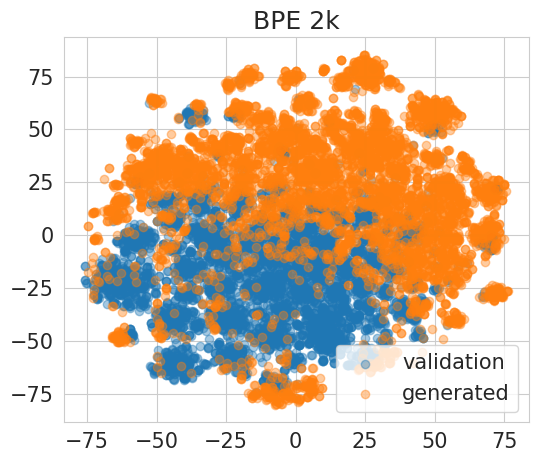

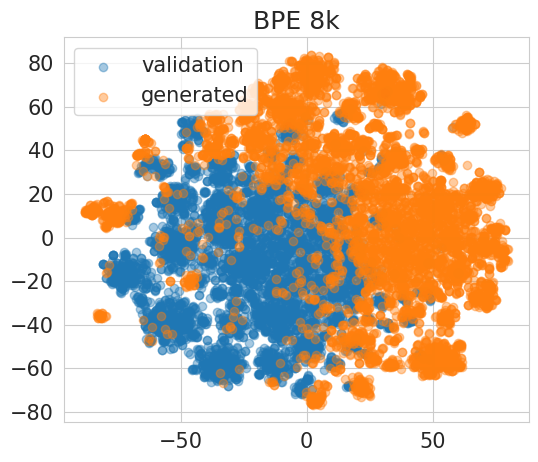

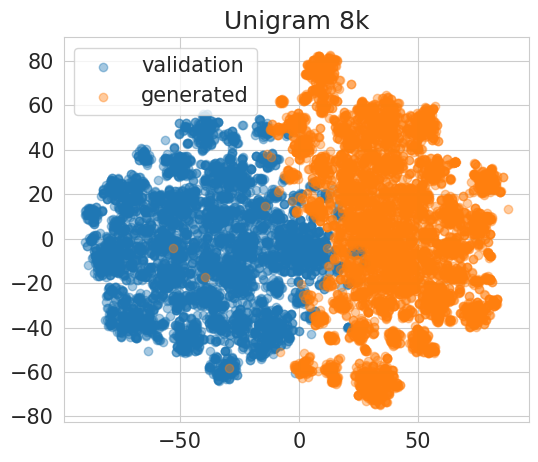

In [40]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

models_data = {
    'BPE 2k': lsa_vectors_2k,
    'BPE 8k': lsa_vectors_8k,
    'Unigram 8k': lsa_vectors_uni
}

for name, lsa_vectors in models_data.items():

    val_vecs = lsa_vectors[:len(val_texts)]
    gen_vecs = lsa_vectors[len(val_texts):]
    X = np.vstack([val_vecs, gen_vecs])
    y = np.array([0]*len(val_vecs) + [1]*len(gen_vecs))
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_2d = tsne.fit_transform(X)
    plt.figure(figsize=(6,5))
    plt.scatter(X_2d[y==0, 0], X_2d[y==0, 1], alpha=0.4, label="validation")
    plt.scatter(X_2d[y==1, 0], X_2d[y==1, 1], alpha=0.4, label="generated")
    plt.title(name)
    plt.legend()
    plt.show()

семинарист по МО-2 Филипп Ульянкин нам доказывал что tsne — это исключительно инструмент “посмотреть красивые картинки” тем не менее, визуализация позволяет интуитивно оценить, насколько распределение сгенерированных текстов похоже на валидационные. для bpe 8k и особенно bpe 2k наблюдается заметное перекрытие облаков точек, что говорит о близости сгенерированных текстов к реальному распределению. d случае Unigram 8k кластеры практически полностью разделены что указывает на существенное отличие генерации от валидационных данных

## Задание 8. ruGPT perplexity (3.5 балла)

Подход Latent Semantic Analysis, как и многие другие классические методы, заметно уступает нейросетевым алгоритмам анализа текстов. Вернемся к оцениванию качества генерации с помощью perplexity, для этого возьмем большую и хорошо обученную языковую модель, которая училась на огромном корпусе русских текстов. Считается, что большие языковые модели хорошо выучивают естественный язык, потому с их помощью мы сможем оценивать качество наших маленьких моделей для генерации анекдотов. Для этого мы воспользуемся сервисом [HuggingFace](https://huggingface.co/), который содержит огромное число обученных моделей для самых разных задач. Изучите и реализуйте, [подсчет perplexity](https://huggingface.co/docs/transformers/perplexity), с использованием обученной языковой модели. В качестве модели возьмите [ruGPT3-small](https://huggingface.co/sberbank-ai/rugpt3small_based_on_gpt2). Сгенерируйте синтетические выборки тремя моделями, обученными выше (можете взять выборки из задания 6), и сравните их по perplexity.

In [41]:
pip install transformers sentencepiece

Note: you may need to restart the kernel to use updated packages.


In [43]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
model_name = "sberbank-ai/rugpt3small_based_on_gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
gpt_model = GPT2LMHeadModel.from_pretrained(model_name).to(device)
gpt_model.eval()

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/574 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/551M [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50264, 768)
    (wpe): Embedding(2048, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50264, bias=False)
)

In [46]:
def get_ppl(text, model, tokenizer):
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        loss = model(**inputs, labels=inputs["input_ids"]).loss
    return torch.exp(loss).item()


results = {}
my_models = {
    "Vanilla": model,
    "BPE 8k": model_bpe8k,
    "Unigram": model_uni
}

for name, net in my_models.items():
    samples = [net.inference() for _ in range(50)]
    ppls = [get_ppl(s, gpt_model, tokenizer) for s in samples]
    results[name] = sum(ppls) / len(ppls)
    print(f"Средняя перплексия для {name}: {results[name]:.2f}")

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Средняя перплексия для Vanilla: 1761.46
Средняя перплексия для BPE 8k: 2684.64
Средняя перплексия для Unigram: 10091.04


ну в целом всё логично. Vanilla получилась лучше всех, BPE 8k похуже, а Unigram вообще сильно отстала — перплексия у неё огромная, что совпадает с тем, что текст у неё самый разваленный

## Бонус (0.1 балл)

Покажите лучший анекдот, который удалось сгенерировать вашей модели. Если проверяющий найдет его смешным, то поставит 0.1 балла.

у меня жена с любовником. я снова не знаю, что делать, когда у тебя нет никого нет.